In [ ]:
import sys
import os 
import numpy as np
import pandas as pd
from loguru import logger
from sklearn import datasets
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
import shap
from scipy.stats import variation 
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from scripts.calculate_ale import ale_plot_modified

d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Loading the Dataset

Define our response `y` and predictor, `X`, variables.

In [2]:
pd.set_option('display.max_columns', None)
df= pd.read_csv("../sampling_test/all_samples.csv")

In [3]:
df.head()

,Unnamed: 0,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,i0_c_ref,kappa_co,kappa_c,Ucell_0,Ucell_1,Ucell_2,Ucell_3,Ucell_4,Ucell_5,Ucell_6,Ucell_7,Ucell_8,Ucell_9,Ucell_10,Ucell_11,Ucell_12,Ucell_13,Ucell_14,Ucell_15,Ucell_16,Ucell_17,Ucell_18,Ucell_19,Ucell_20,Ucell_21,Ucell_22,Ucell_23,Ucell_24,Ucell_25,Ucell_26,Ucell_27,Ucell_28,Ucell_29,Ucell_30
0,0,345.931298,268431.866782,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.95271,1.033675,0.989722,0.957810,0.932335,0.911016,0.892687,0.876653,0.862455,0.849772,0.838364,0.828070,0.821914,0.819564,0.810346,0.802222,0.794046,0.785436,0.776472,0.767254,0.757903,0.748495,0.739037,0.729581,0.720127,0.710685,0.701266,0.691858,0.682437,0.672987,0.663492,0.653933
1,1,350.820492,268431.866782,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.95271,1.021434,0.975872,0.942075,0.914629,0.891312,0.870973,0.852928,0.836730,0.822068,0.808716,0.796480,0.785223,0.774845,0.765254,0.756370,0.748125,0.740463,0.733342,0.735180,0.736204,0.728517,0.721292,0.714529,0.707308,0.699520,0.691411,0.682963,0.674201,0.665215,0.656067,0.646718
2,2,345.931298,201919.596742,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.95271,1.036704,0.977552,0.937420,0.905870,0.879454,0.856565,0.836299,0.818097,0.801583,0.786491,0.772624,0.759830,0.747991,0.737011,0.726808,0.717314,0.708470,0.700170,0.692394,0.685115,0.678300,0.671943,0.674925,0.678619,0.672719,0.664526,0.658328,0.651771,0.644673,0.636798,0.628506
3,3,345.931298,268431.866782,1.789658,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.95271,1.022000,0.984157,0.956984,0.935272,0.917519,0.902636,0.889036,0.876317,0.864211,0.852340,0.840609,0.829272,0.818282,0.807534,0.796987,0.786608,0.776368,0.766241,0.756208,0.746247,0.736336,0.726456,0.716600,0.706744,0.696881,0.686989,0.677044,0.667028,0.656922,0.646707,0.636362
4,4,345.931298,268431.866782,2.632068,0.145910,0.624495,3.51943,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.95271,1.033369,0.989841,0.958218,0.932968,0.911835,0.893663,0.877764,0.863683,0.851100,0.839778,0.829771,0.825820,0.820896,0.811462,0.803161,0.794714,0.785849,0.776625,0.767277,0.757837,0.748334,0.738844,0.729362,0.719902,0.710475,0.701074,0.691673,0.682255,0.672806,0.663305,0.653740


In [4]:
df = df.drop('Unnamed: 0', axis=1)
prefix = 'Ucell'
df['Ucell'] = df.filter(like=prefix).sum(axis=1)
X=df.loc[:, ~df.columns.str.startswith(prefix)]
Y = df['Ucell']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)

In [6]:
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

### Fit a XGBoost

In [7]:


# Define parameter grid (
param_grid = {
    'max_depth': [4, 6],
    'learning_rate': [0.1, 0.3],  # 'eta' is called 'learning_rate' in XGBRegressor
    'reg_lambda': [0, 1],         # L2 regularization
    'reg_alpha': [0, 0.5],        # L1 regularization
}

# Initialize XGBRegressor
xgb_model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=50,
    nthread=4,
    eval_metric='rmse'
)

# GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

# Fit to training data
grid_search.fit(X_train, y_train)

# Best parameters and score
print("Best params:", grid_search.best_params_)
print("Best RMSE:", -grid_search.best_score_)


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params: {'learning_rate': 0.3, 'max_depth': 6, 'reg_alpha': 0.5, 'reg_lambda': 1}
Best RMSE: 16.57471817908855


In [8]:
# Best estimator from grid search
best_model = grid_search.best_estimator_

# Predict on the test set
y_pred = best_model.predict(X_test)

# Calculate RMSE on the test set
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
print("Test RMSE:", rmse_test)


Test RMSE: 22.244166974154812


## Create our ALE Plots

### 1D Main Effect ALE Plot

In [9]:
import matplotlib as mpl

from alepython import ale_plot

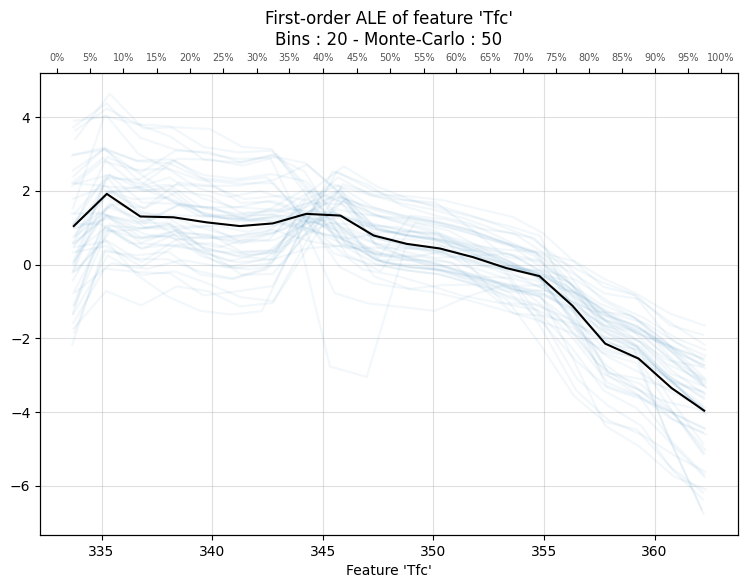

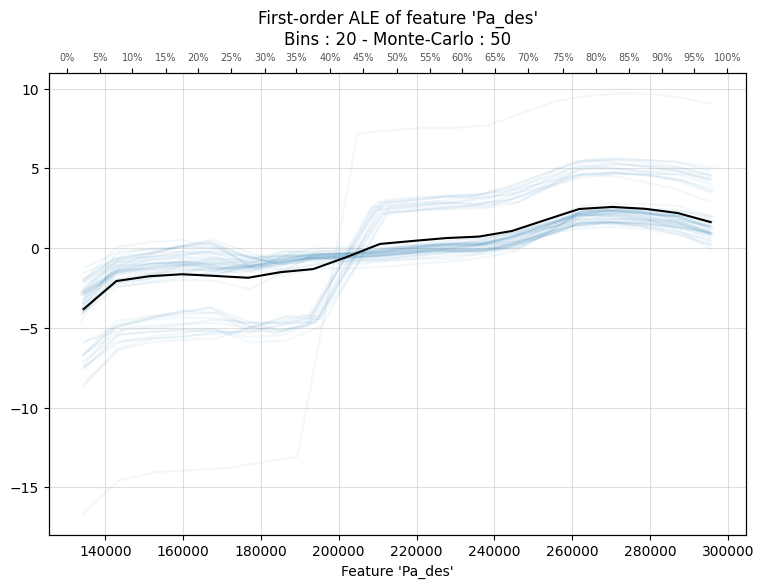

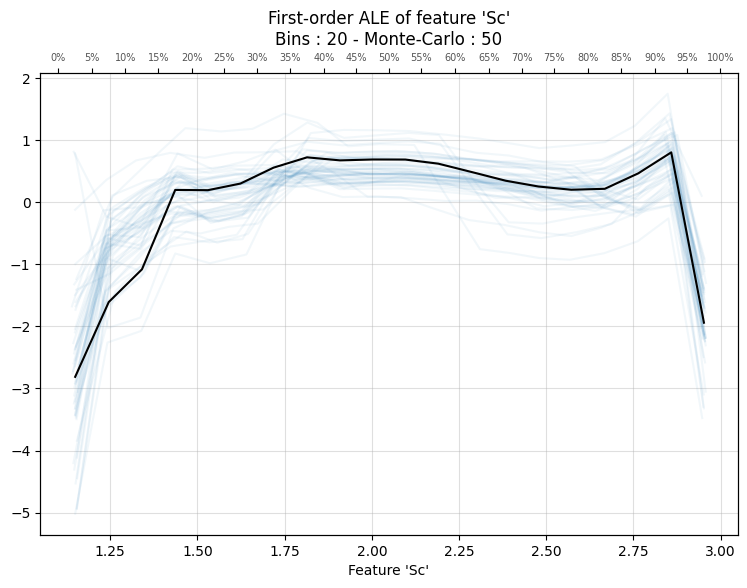

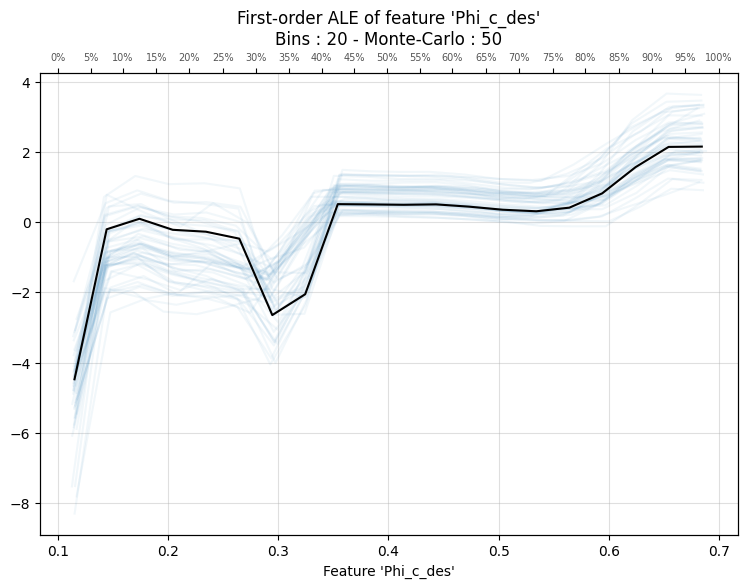

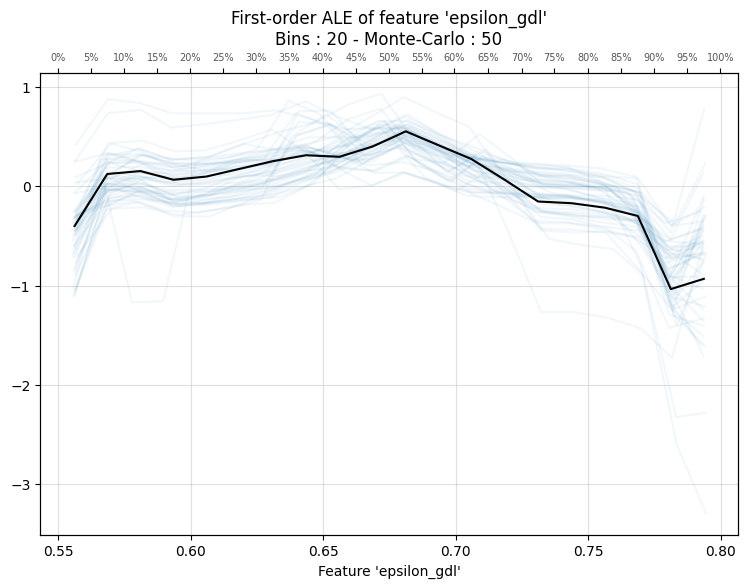

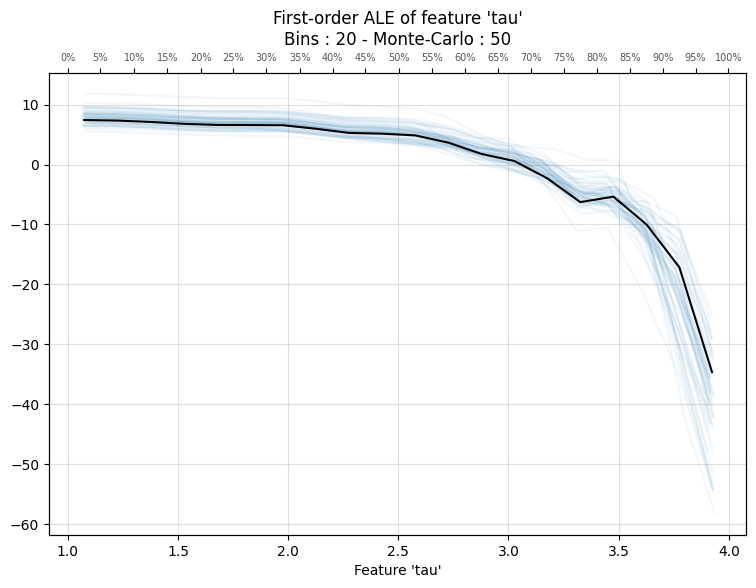

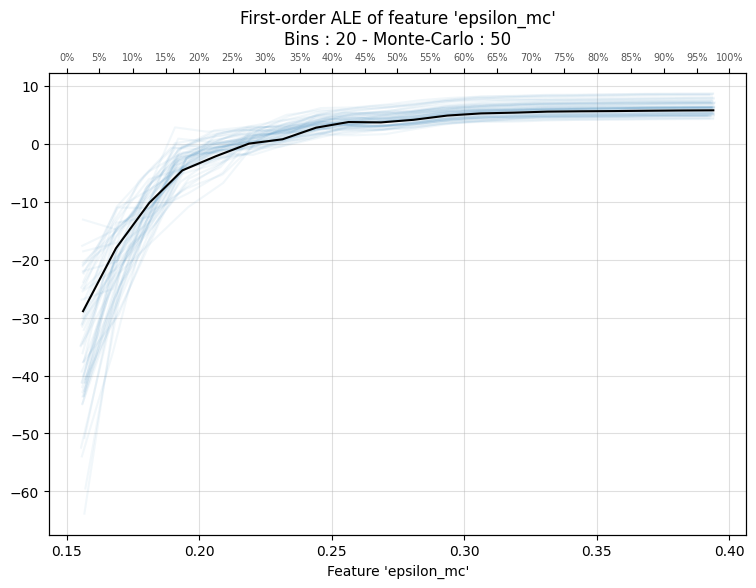

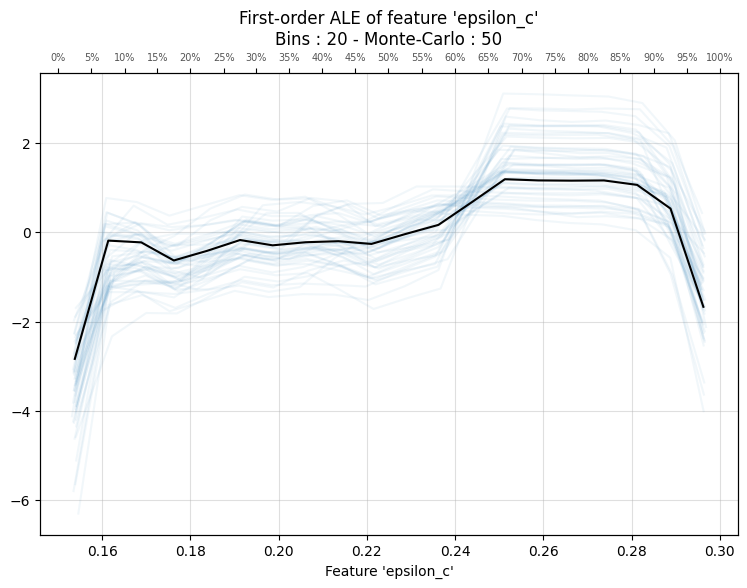

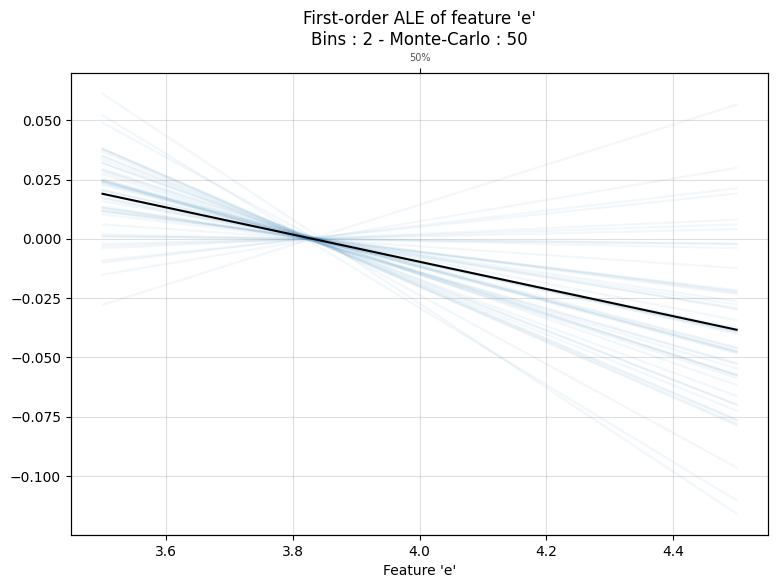

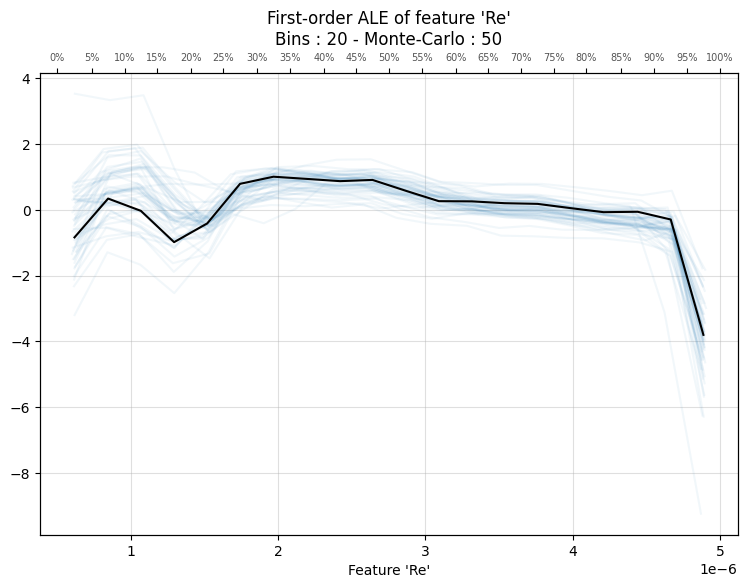

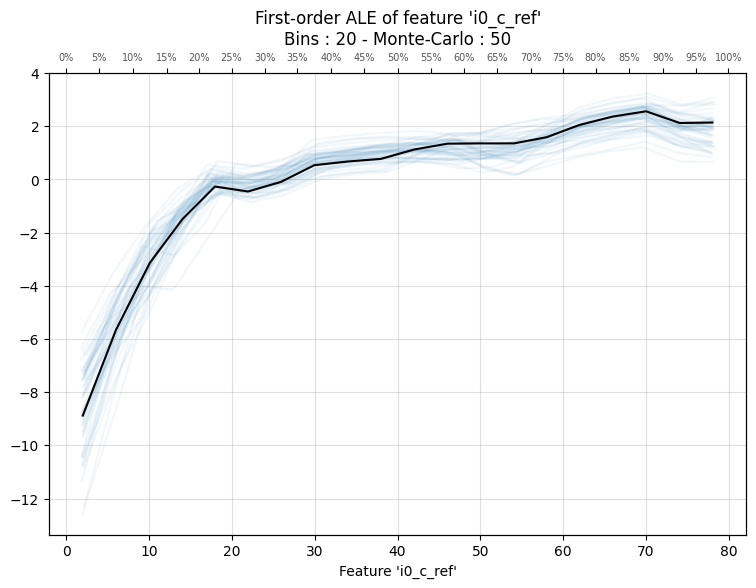

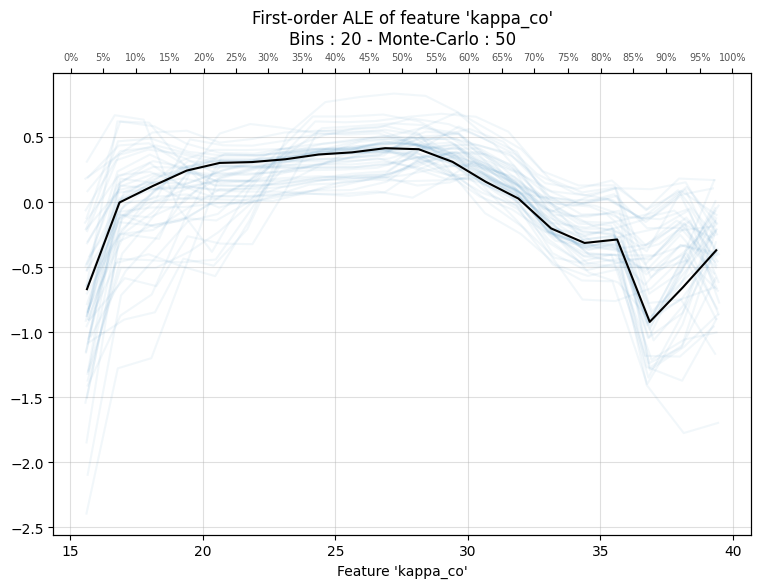

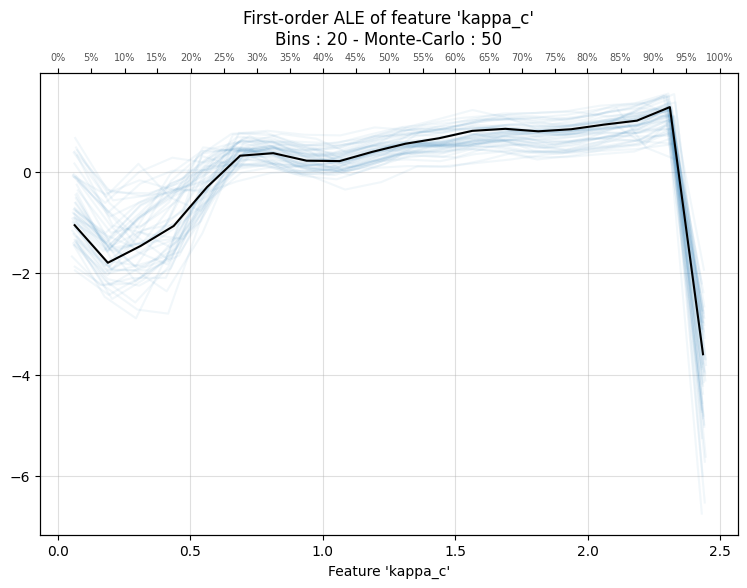

In [26]:
results_ale = []
for i, feature in enumerate(X.columns.to_list()):
    mpl.rc("figure", figsize=(9, 6))
    ale,quantile = ale_plot_modified(
        best_model,
        X,
        feature,
        bins=20,
        monte_carlo=True,
        monte_carlo_rep=50,
        monte_carlo_ratio=0.1,
    )
    results_ale.append((feature,ale))

In [27]:
dicc_res = {res[0]: {'mean': np.mean(res[1]), 'sd': np.std(res[1]), 'cv': variation(res[1])} for res in results_ale}
dicc_res_df = pd.DataFrame.from_dict(dicc_res,orient='index')
dicc_res_df.sort_values('sd',ascending=False)
#dicc_res_df.sort_values(by='cv', key=lambda x: x.abs(), ascending=False)

,mean,sd,cv
tau,-0.009992,10.333550,-1034.197576
epsilon_mc,0.006117,8.985288,1468.816732
i0_c_ref,0.002258,2.821461,1249.406036
Pa_des,0.002630,1.833098,696.934308
Tfc,-0.000958,1.672914,-1746.482277
Phi_c_des,0.002202,1.510800,686.068011
kappa_c,-0.000157,1.185700,-7532.295264
Re,-0.000127,1.029277,-8101.190988
Sc,0.000395,0.990070,2505.502359
epsilon_c,0.000291,0.977460,3362.345989


## PD- plots

In [ ]:
X100 = shap.utils.sample(X, 100) #SHAP uses this to understand the baseline behavior of the model.
explainer_xgb = shap.Explainer(best_model, X100)
shap_values_xgb = explainer_xgb(X)

 98%|===================| 28028/28651 [00:36<00:00]        

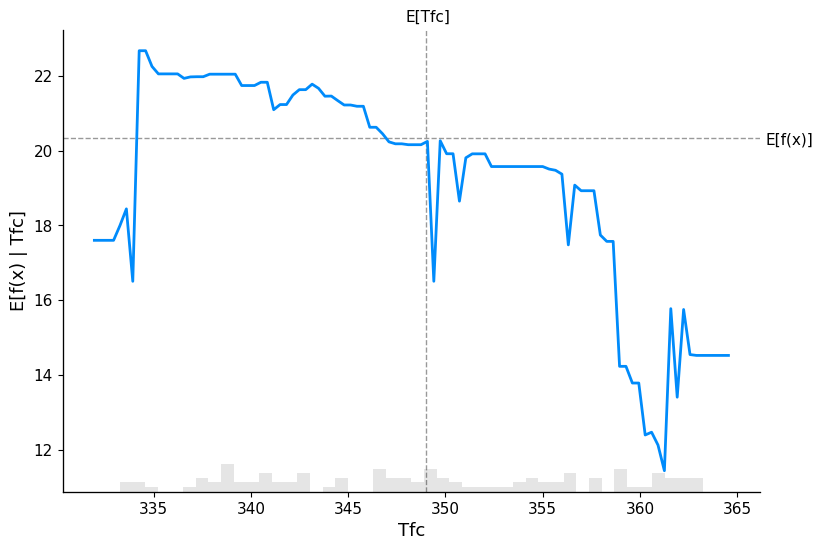

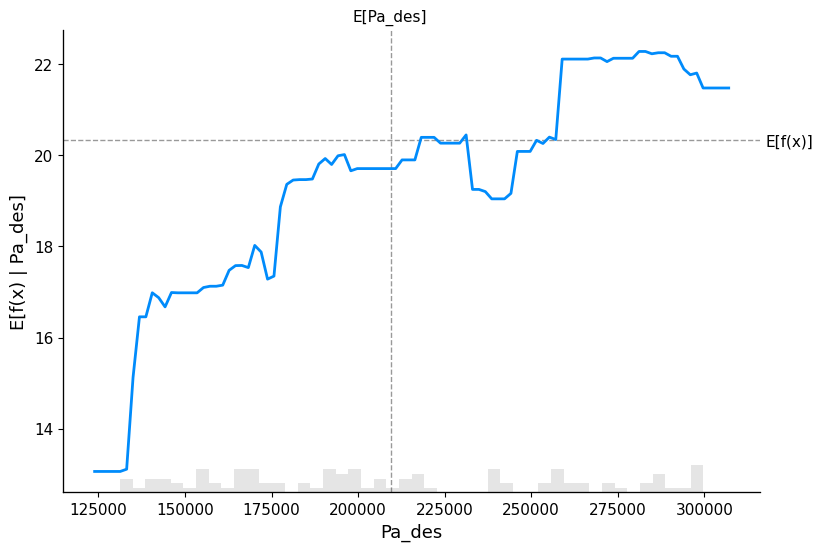

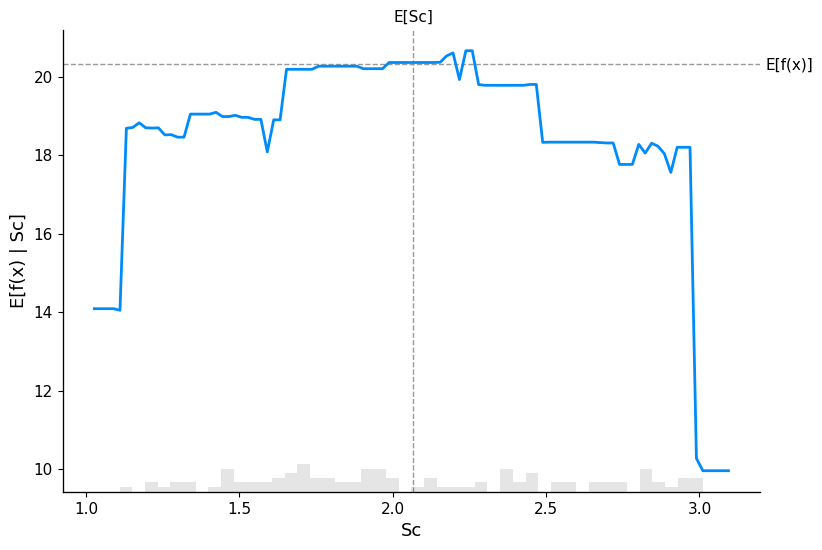

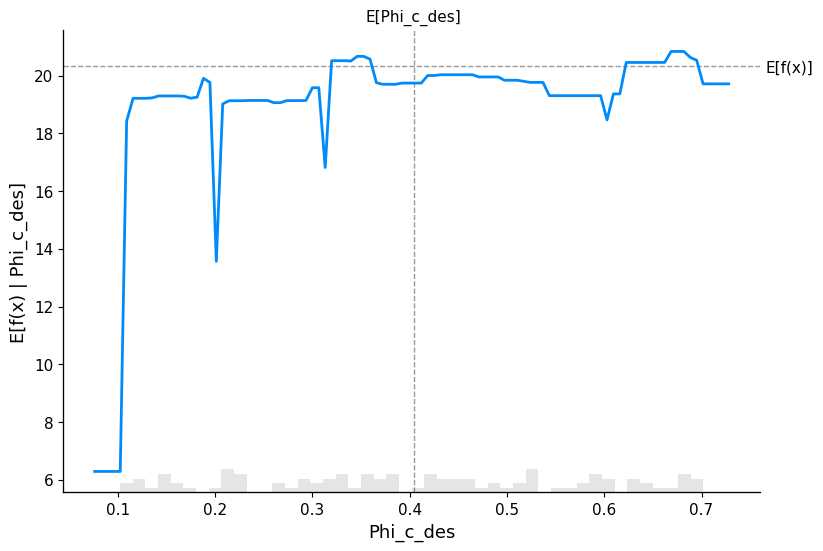

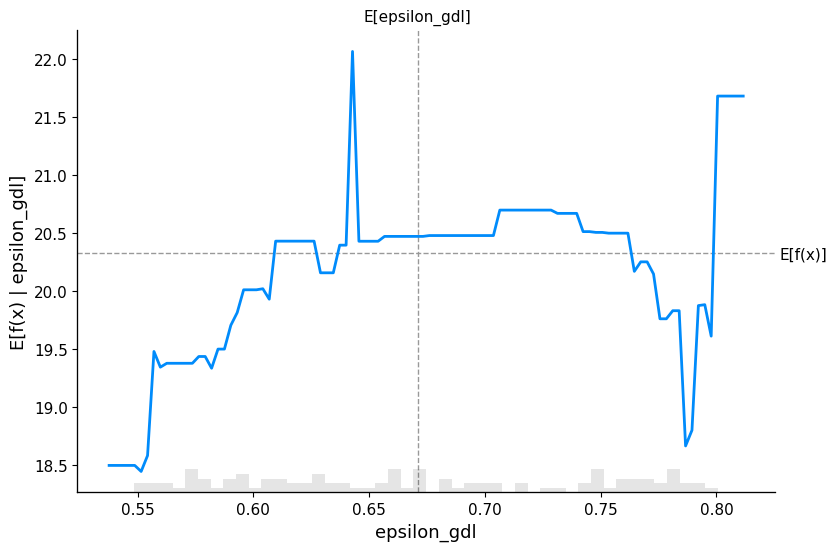

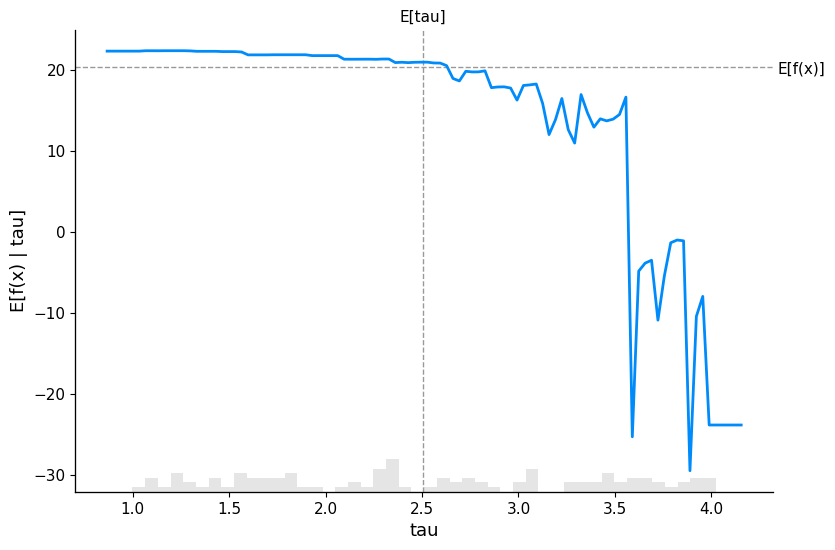

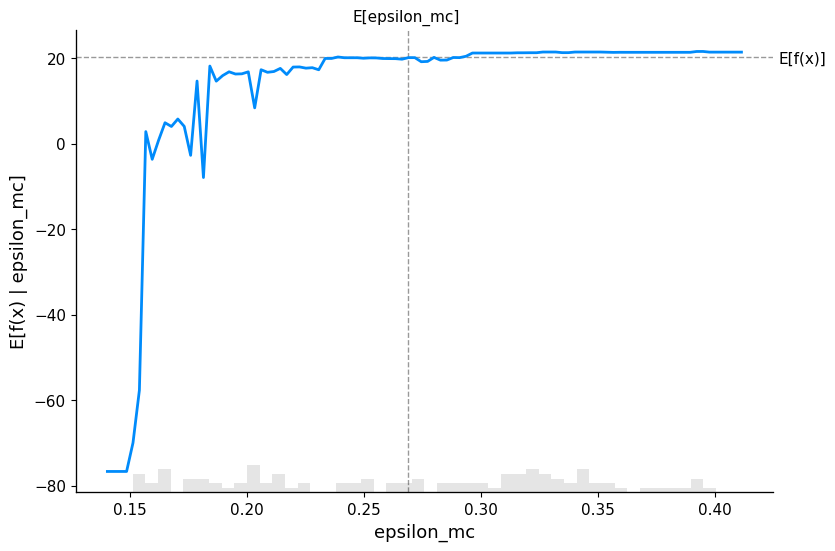

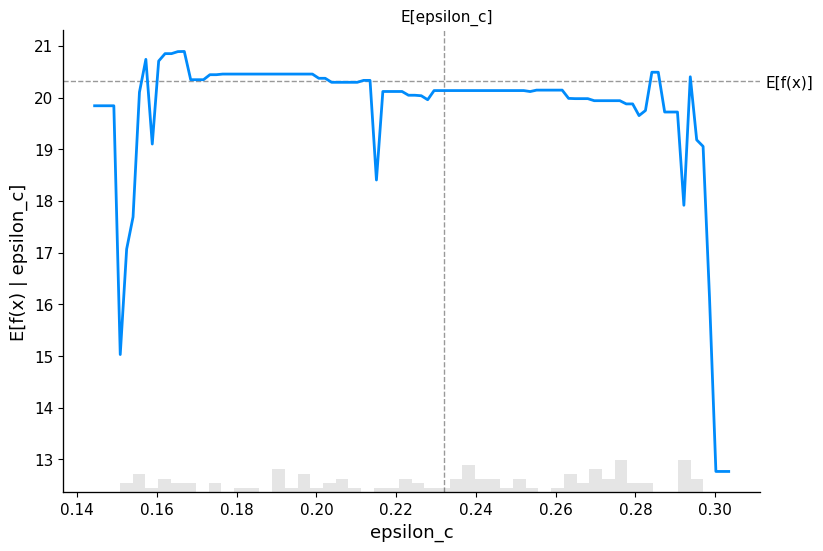

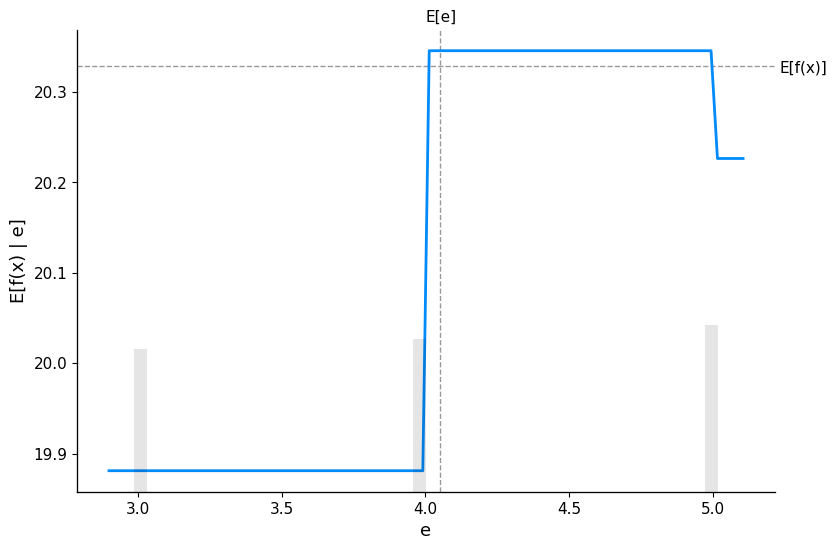

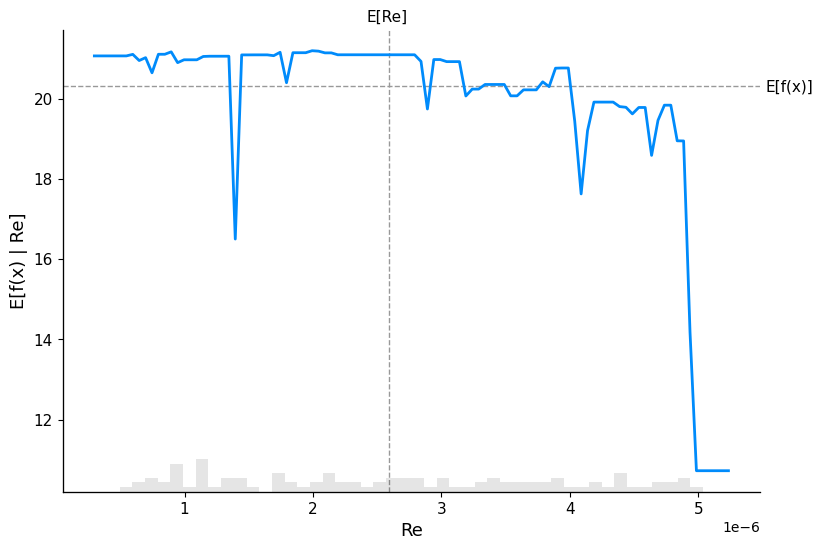

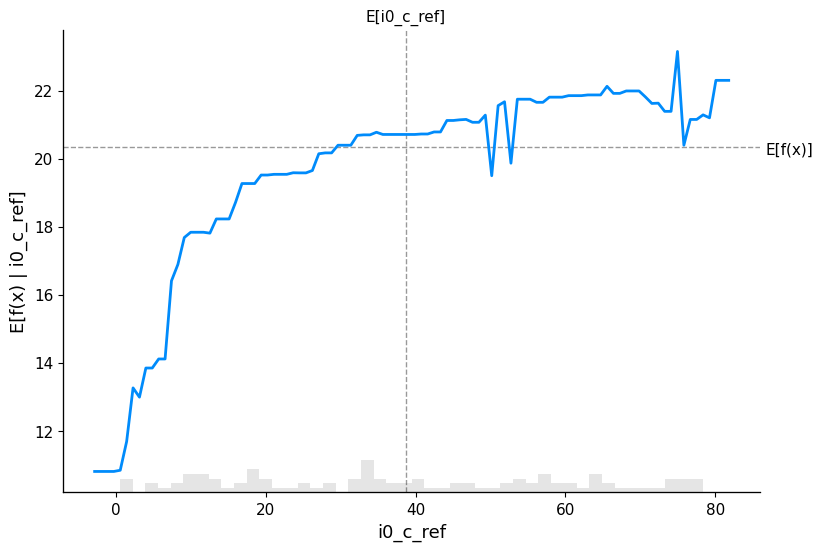

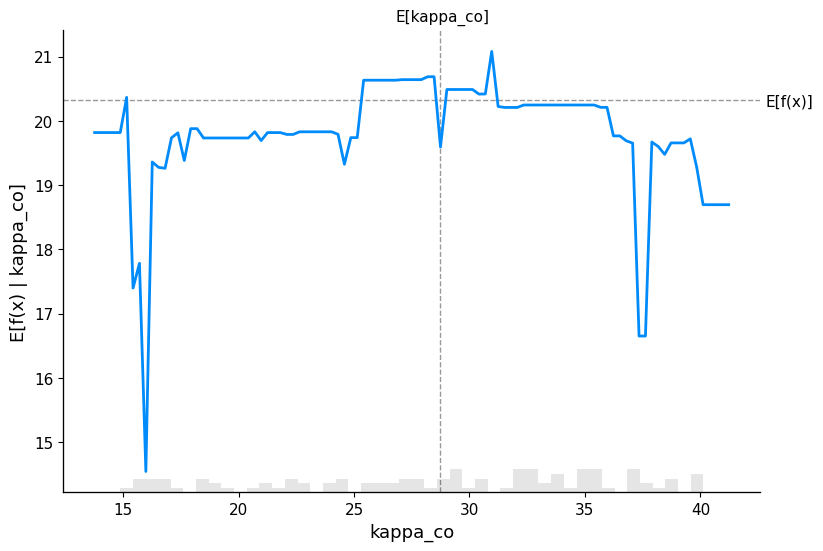

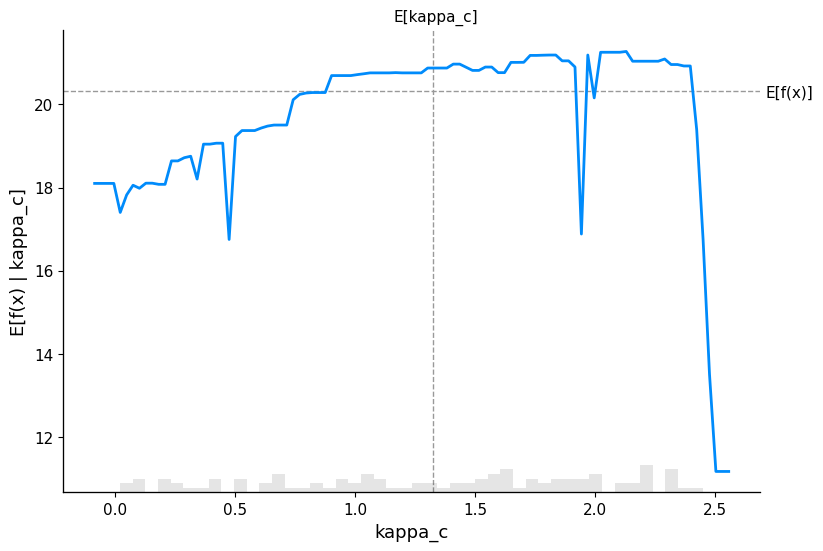

In [47]:
# make a standard partial dependence plot with a single SHAP value overlaid
for i, feature in enumerate(X.columns.to_list()):
    fig, ax = shap.partial_dependence_plot(
        feature,
        best_model.predict,
        X100,
        model_expected_value=True,
        feature_expected_value=True,
        show=False,
        ice=False#,
        #shap_values=shap_values_xgb[sample_ind : sample_ind + 1, :],
    )

## SHAP values

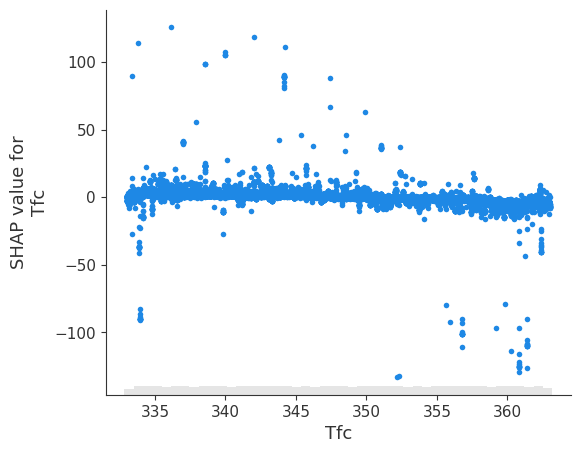

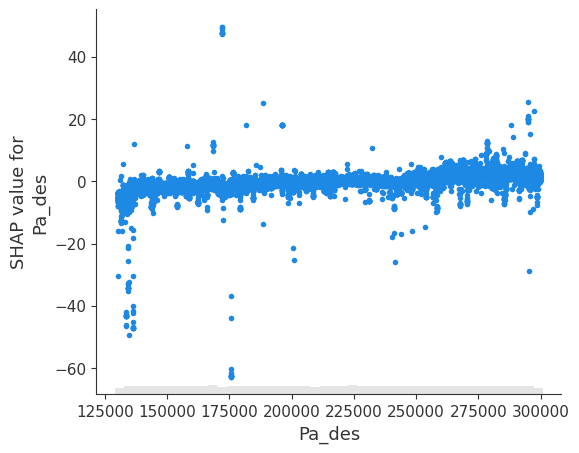

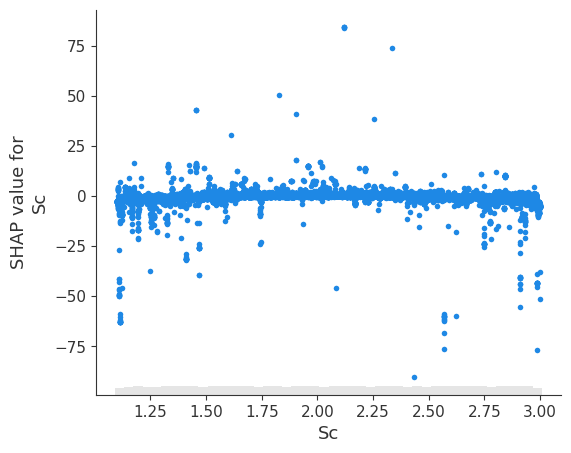

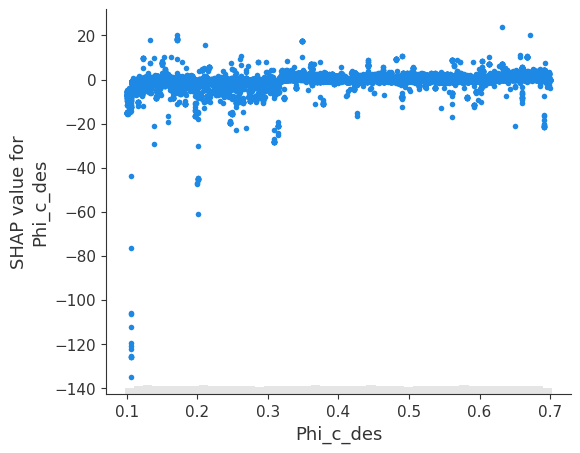

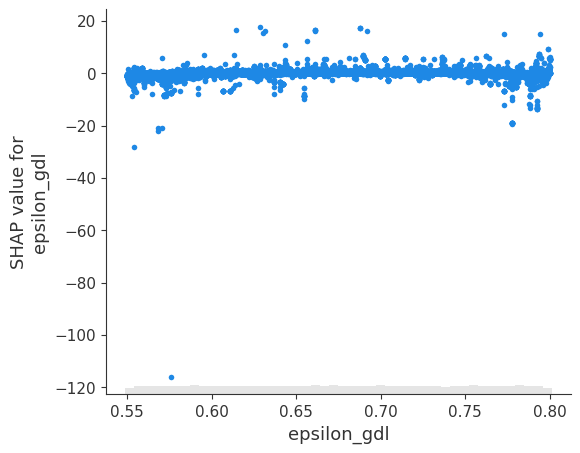

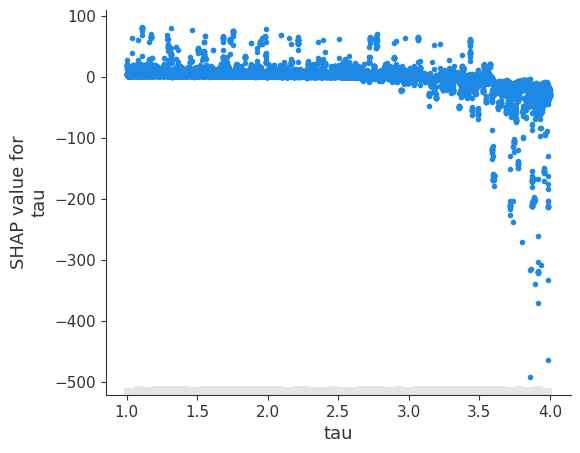

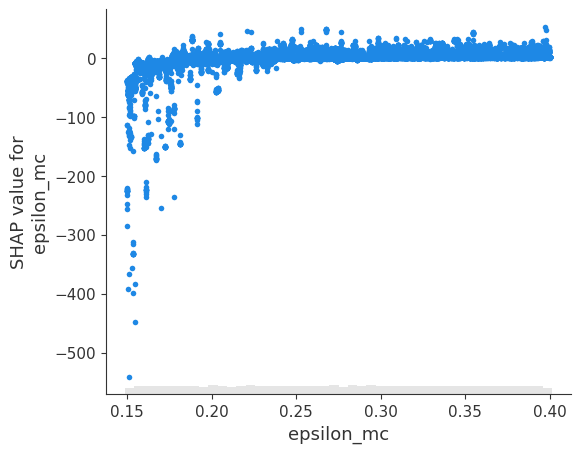

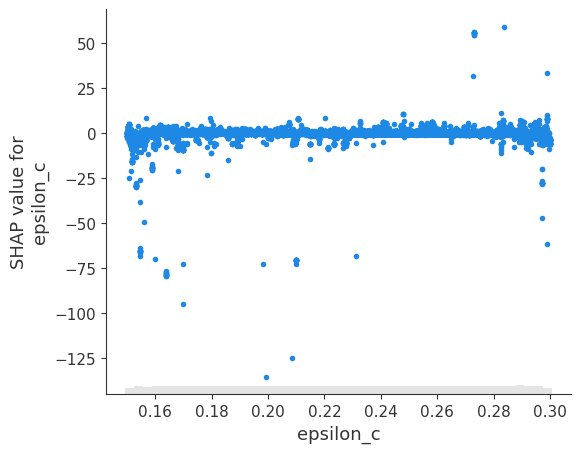

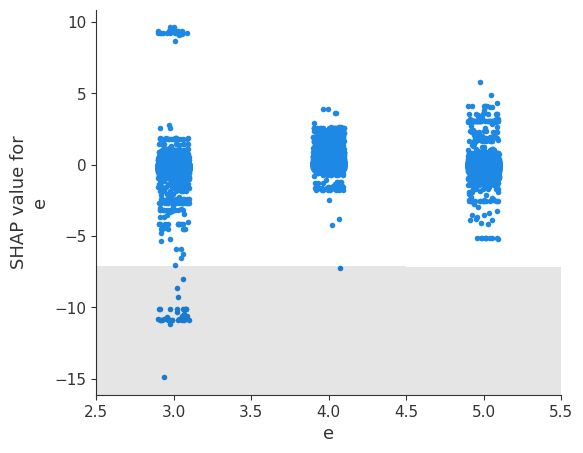

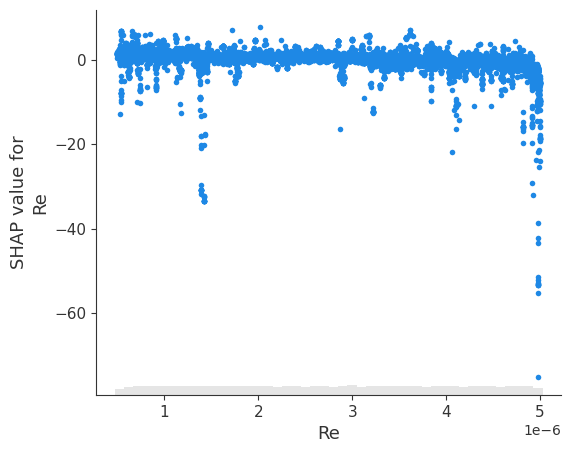

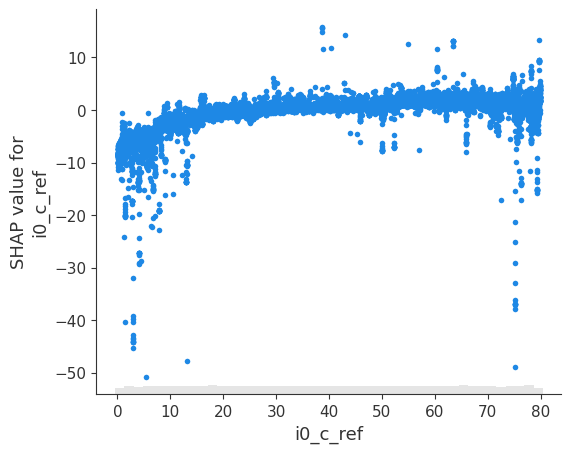

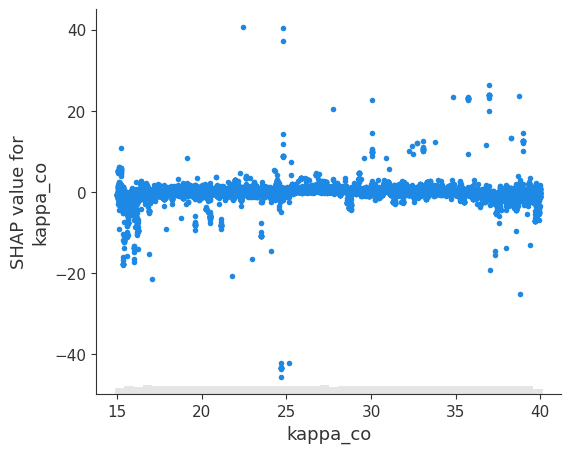

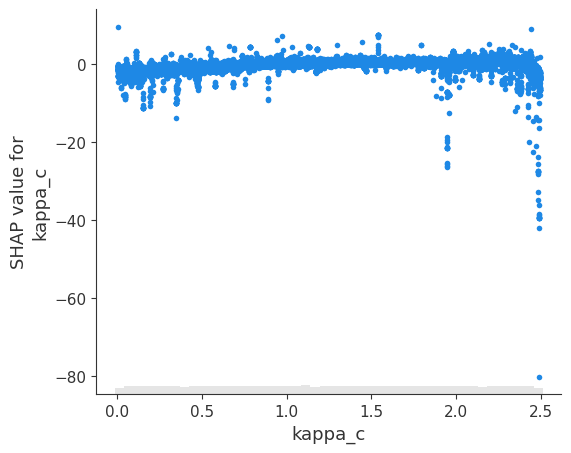

In [50]:
for i, feature in enumerate(X.columns.to_list()):
    shap.plots.scatter(shap_values_xgb[:, feature])#, color=shap_values_xgb)

## Global SHAP

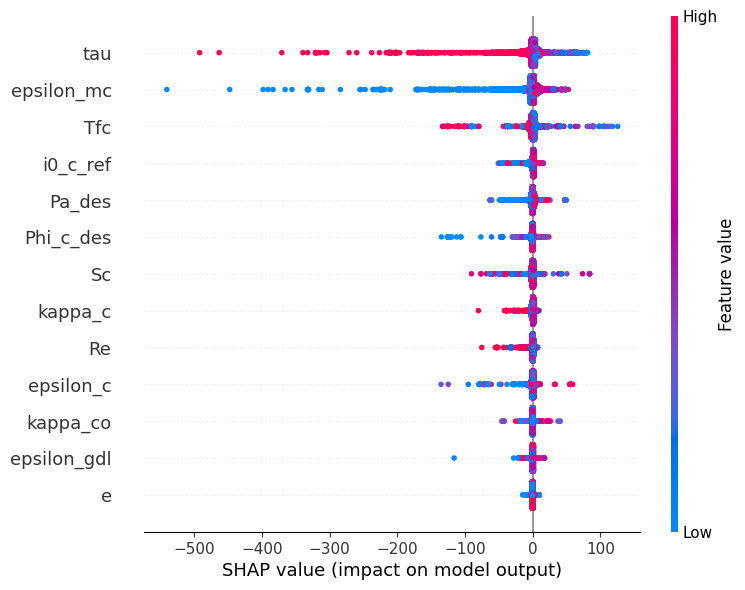

In [53]:
shap.plots.beeswarm(shap_values_xgb, max_display=13)

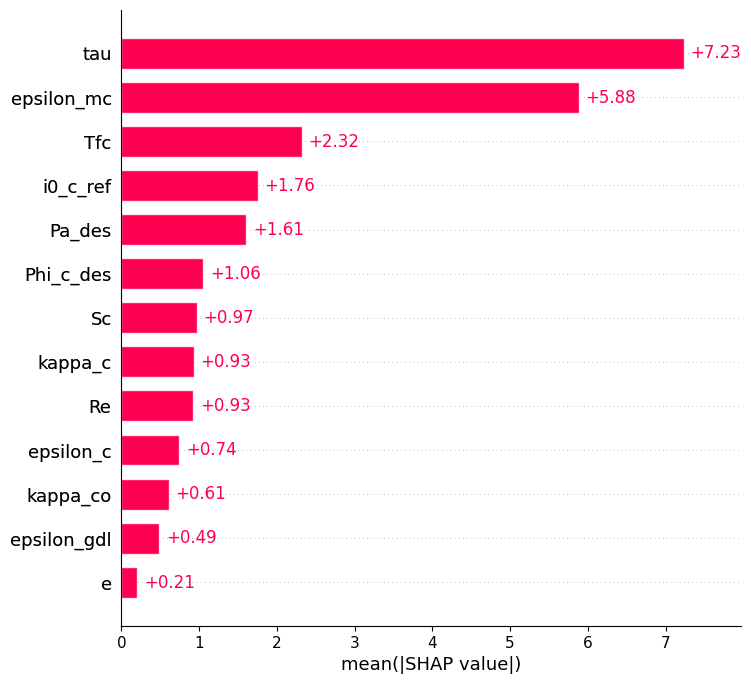

In [51]:
shap.plots.bar(shap_values_xgb, max_display=13)